# **Notebook 2 - Customer Segmentation** 

Afonso Fernandes 20241710, Lourenço Lima 20241711, Lucas Casimiro 20241796

## Imports

In [13]:
import os
import sys
import warnings
from pathlib import Path

def _find_project_root(start, marker="requirements.txt"):
    path = Path(start).resolve()
    for candidate in [path] + list(path.parents):
        if (candidate / marker).exists():
            return str(candidate)
    raise RuntimeError(f"Could not find project root (marker={marker!r}, searched from {start})")

PROJECT_ROOT = _find_project_root(os.path.abspath("."))
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors
import seaborn as sns
import plotly.express as px
from pylab import rcParams
rcParams['figure.figsize'] = 30, 15
import umap

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import confusion_matrix
from scipy.cluster.hierarchy import dendrogram, linkage
from functions.preprocessing import scale_features, FEATURE_COLS
from functions.clustering import *

import warnings
warnings.filterwarnings('ignore', category = FutureWarning)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## **Scaling**

Before proceeding, we will save 3 scaled datasets using 3 different scalers, to see which one gives the better results.

In [15]:
clean_data = pd.read_csv('data/ci_clustering.csv')
clean_data

,customer_id,customer_name,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,typical_hour,lifetime_total_distinct_products,percentage_of_products_bought_promotion,...,omnivore,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood
0,3,Bsc. Crystal Kitchens,female,1.0,1.0,1.0,3.0,12.0,189.0,0.631599,...,1,0.244917,0.020065,0.017375,0.009521,0.001506,0.011458,0.029693,0.013771,0.020656
1,4,Bsc. Glenda Bauman,female,1.0,0.0,0.0,2.0,12.0,130.0,0.149890,...,1,0.047596,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.016458,0.032867
2,5,Msc. Antonio Campbell,male,0.0,0.0,0.0,2.0,11.0,81.0,0.069126,...,1,0.000000,0.035694,0.006496,0.007589,0.081356,0.017557,0.032607,0.006496,0.014277
3,7,John Kelling,male,0.0,0.0,2.0,1.0,18.0,92.0,0.253609,...,1,0.073903,0.005618,0.050629,0.075776,0.065008,0.072432,0.032437,0.110754,0.012306
4,8,Arthur Dematteo,male,0.0,0.0,3.0,1.0,17.0,6.0,0.186569,...,1,0.420243,0.014730,0.022948,0.027833,0.041400,0.039346,0.011513,0.048765,0.017095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31773,39996,Joshua Howard,male,0.0,0.0,2.0,1.0,12.0,162.0,0.261352,...,1,0.677108,0.009538,0.028765,0.049900,0.051205,0.057932,0.003112,0.080221,0.018373
31774,39997,Anthony Hines,male,1.0,0.0,1.0,1.0,21.0,97.0,0.143479,...,1,0.488076,0.009858,0.016836,0.048001,0.044817,0.020393,0.007453,0.071308,0.007690
31775,39998,Edna Hasselman,female,1.0,1.0,0.0,4.0,14.0,206.0,0.181917,...,0,0.105017,0.113532,0.035053,0.008302,0.021784,0.000000,0.121975,0.006315,0.018307
31776,39999,George Kramer,male,1.0,1.0,1.0,6.0,11.0,385.0,0.807259,...,0,0.225881,0.043232,0.021979,0.047947,0.000000,0.008197,0.029740,0.000000,0.016321


In [18]:
# Standard Scaler
clean_std = scale_features(clean_data.copy(), StandardScaler)

# Robust Scaler
clean_rb = scale_features(clean_data.copy(), RobustScaler)

# MinMax Scaler
clean_minmax = scale_features(clean_data.copy(), MinMaxScaler)

## **Clustering**

The cluster analysis in the notebook is separated by scalers, and in each section 2 algorithms will be tested: `K-means` and `Hierarchical (Ward linkage)`. 

For each scaler section, 3 tasks are developed:
 - **Mathematical Comparison**: silhouette scores (a common analysis between both models) is used as a comparison between algorithms and plotted for each amount of clusters.
 - **Visual Inspection**: an elbow method is plotted to decide an amount for k in K-means, and a dendrogram is plotted to decide the amount of clusters created by Hierarchical Ward algorithm.
 - **Cluster Analysis**: collect insights based on the clusters created from both algorithms (profiling).
  
We specifically use the *Ward* linkage for our hierarchical model because it minimizes within-cluster variance (the exact same mathematical objective as K-Means). Below is proof of this linkage method superiority.

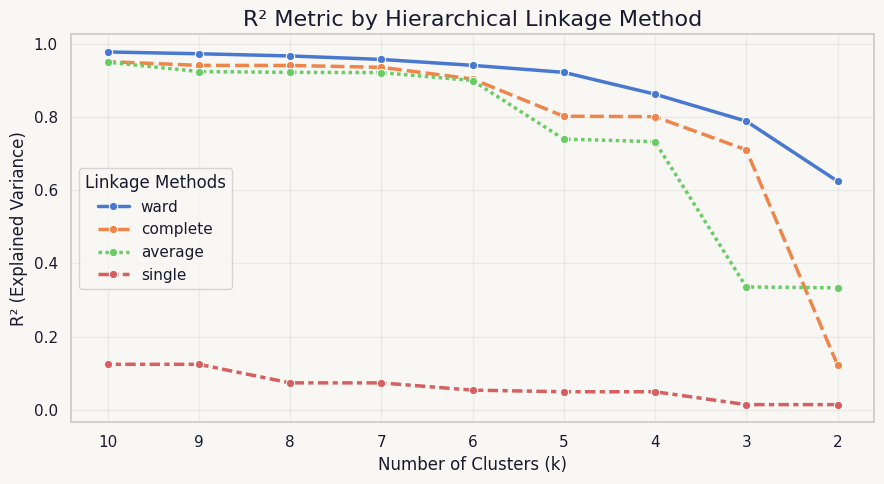

In [24]:
plot_r2_hc(clean_data, FEATURE_COLS)

## **Standard Scaler**

### Mathematical Comparison

In [28]:
results_std = compare_clustering_models(clean_std, FEATURE_COLS)
results_std

,model,k,silhouette
0,hierarchical_ward,7,0.127731
1,kmeans,5,0.122399
2,kmeans,8,0.121877
3,kmeans,7,0.121773
4,hierarchical_ward,3,0.121037
5,kmeans,6,0.118915
6,kmeans,10,0.117876
7,hierarchical_ward,6,0.117542
8,hierarchical_ward,9,0.116323
9,hierarchical_ward,8,0.113295


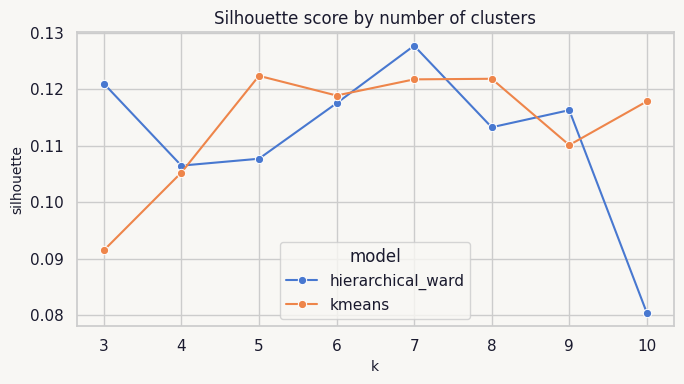

In [27]:
plot_metric_comparison(results_std)

### Visual Inspection

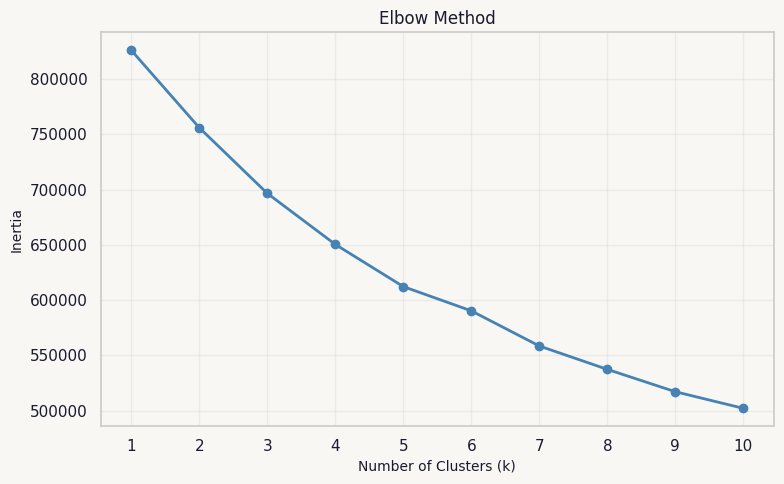

,k,inertia
0,1,826228.000000
1,2,756140.226756
2,3,696720.869771
3,4,650499.342274
4,5,612317.455687
5,6,590347.421723
6,7,558541.388993
7,8,537391.809165
8,9,517149.450675
9,10,502118.732406


In [44]:
compare_kmeans_inertia(clean_std, FEATURE_COLS)

The elbow curve shows no definitive optimal number of clusters, as there's no clear sharp degree. However, k=5 could be a good result, as there's a bigger drop between 6 and 7 compared to 5 and 6, and its supported by the silhouette score as the best result for k-means (with this scaler).

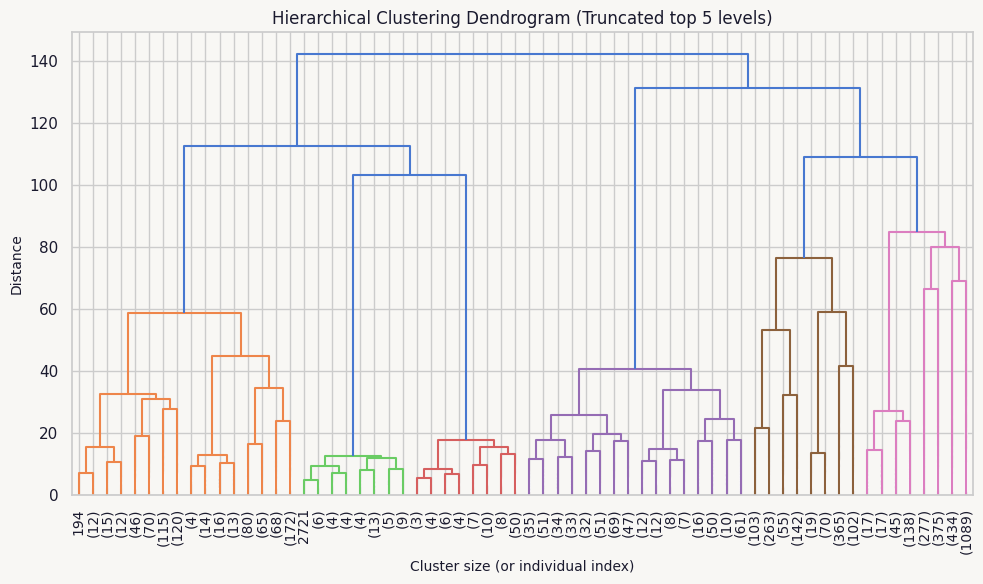

In [49]:
plot_dendrogram(clean_std, FEATURE_COLS)

The first small drop in distance comes at either 5 or 7 clusters (depending on what we consider small). Supported by the silhouette score analysis, we will proceed with 7 clusters for the hierarchical clustering.

### Cluster Analysis

In [63]:
optimal_k_kmeans_std = 5
optimal_k_ward_std = 7

In [ ]:
kmeans_labels_std, kmeans_model_std = fit_final_kmeans(clean_std, FEATURE_COLS, n_clusters=optimal_k_kmeans_std)
final_std_k = add_clusters(clean_data, kmeans_labels_std, cluster_col='std_kmeans5')

calculate_group_means(final_std_k, cluster_col='std_kmeans5')

std_kmeans5,0,1,2,3,4
customer_id,19921.367491,19060.405927,20250.169806,19800.029539,20890.665865
kids_home,1.025913,1.571572,0.252909,1.015020,0.982201
teens_home,0.845701,1.375377,0.297507,0.864820,0.611699
number_complaints,0.698469,0.827861,0.965651,0.653037,1.123148
distinct_stores_visited,3.420495,3.301564,1.547091,3.411048,3.358187
typical_hour,12.293286,11.325986,17.625762,12.418725,12.357033
lifetime_total_distinct_products,104.176678,241.334583,100.405540,104.159212,98.101308
percentage_of_products_bought_promotion,0.162648,0.277096,0.266001,0.133681,0.512699
year_first_transaction,2015.689046,2013.048569,2017.698892,2015.630007,2016.429671
latitude,38.754404,38.748754,38.746655,38.755182,38.748069


 - Cluster 0: Only buys meat and fish, mostly average features otherwise
 - Cluster 1: Oldest cluster on average, clearly most loyal (from tenure, loyalty card and year of the first transaction). Has significantly more dependants, and are the highest spenders by a good margin (most distinct products as well).
 - Cluster 2:
 - Cluster 3:
 - Cluster 4:
 - Cluster 5:

In [72]:
ward_labels_std, ward_model_std = fit_final_hierarchical(clean_std, FEATURE_COLS, n_clusters=optimal_k_ward_std)
final_std_ward = add_clusters(clean_data, ward_labels_std, cluster_col='std_ward7')

calculate_group_means(final_std_ward, cluster_col='std_ward7')

std_ward7,0,1,2,3,4,5,6
customer_id,19911.913821,20132.061086,19851.503706,19853.543511,19843.558464,20082.905797,19744.750538
kids_home,1.061905,0.864121,0.299140,1.026485,1.027923,1.021739,3.374552
teens_home,0.655052,0.797700,0.332049,0.875709,0.842932,0.851449,2.720789
number_complaints,1.308362,0.709384,1.034687,0.625236,0.715532,0.663043,0.843369
distinct_stores_visited,3.239837,3.428979,1.581382,3.361521,3.432810,3.394928,3.137634
typical_hour,12.944948,11.709384,17.051290,12.464245,12.465969,11.934783,10.097133
lifetime_total_distinct_products,93.225552,193.124103,104.573970,101.504351,100.403141,112.010870,305.932258
percentage_of_products_bought_promotion,0.517707,0.320384,0.267984,0.131989,0.168743,0.149993,0.207212
year_first_transaction,2016.188153,2014.399448,2017.154462,2015.297011,2015.726003,2015.612319,2013.030108
latitude,38.747681,38.749018,38.748560,38.754934,38.752698,38.757947,38.748103


 - Cluster 0: 
 - Cluster 1: 
 - Cluster 2:
 - Cluster 3:
 - Cluster 4:
 - Cluster 5:
 - Cluster 6:
 - Cluster 7:

## **Robust Scaler**

### Mathematical Comparison

In [32]:
results_rb = compare_clustering_models(clean_rb, FEATURE_COLS)
results_rb

,model,k,silhouette
0,kmeans,3,0.255411
1,hierarchical_ward,3,0.231356
2,kmeans,4,0.194269
3,hierarchical_ward,4,0.172516
4,kmeans,5,0.148354
5,kmeans,6,0.146304
6,kmeans,7,0.138582
7,kmeans,9,0.138182
8,kmeans,8,0.135805
9,kmeans,10,0.132056


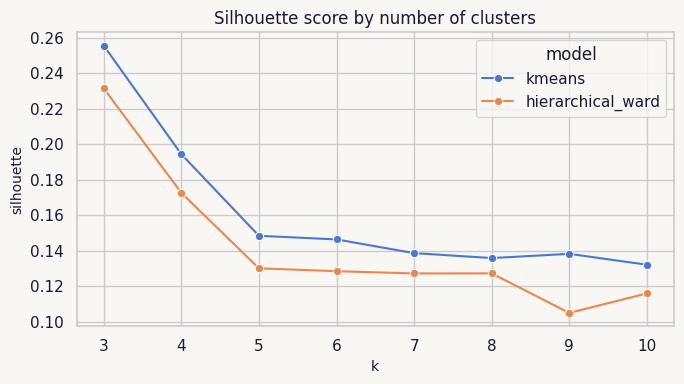

In [33]:
plot_metric_comparison(results_rb)

### Visual Inspection

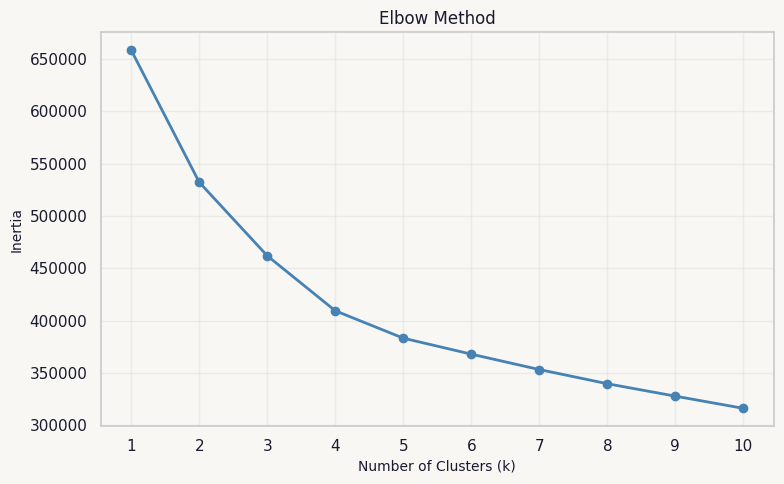

,k,inertia
0,1,658367.609198
1,2,532154.570240
2,3,461866.665684
3,4,409304.204856
4,5,383128.185268
5,6,367831.088032
6,7,353119.695862
7,8,339573.603741
8,9,327678.163902
9,10,316039.148125


In [43]:
compare_kmeans_inertia(clean_rb, FEATURE_COLS)

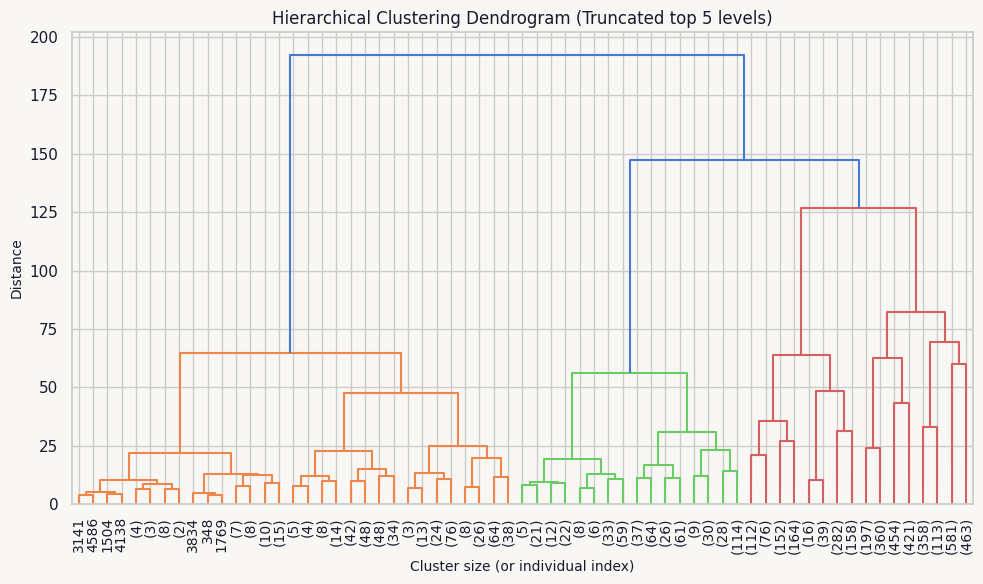

In [54]:
plot_dendrogram(clean_rb, FEATURE_COLS)

### Cluster Analysis

In [ ]:
optimal_k_kmeans_rb = 5
optimal_k_ward_rb = 7

In [ ]:
kmeans_labels_rb, kmeans_model_rb = fit_final_hierarchical(clean_rb, FEATURE_COLS, n_clusters=optimal_k_kmeans_rb)
final_rb_kmeans = add_clusters(clean_data, kmeans_labels_rb, cluster_col='rb_kmeans')

calculate_group_means(final_rb_kmeans, cluster_col='rb_kmeans')

In [ ]:
ward_labels_rb, ward_model_rb = fit_final_hierarchical(clean_rb, FEATURE_COLS, n_clusters=optimal_k_ward_rb)
final_rb_ward = add_clusters(clean_data, ward_labels_rb, cluster_col='rb_ward')

calculate_group_means(final_rb_ward, cluster_col='rb_ward')

## **MinMax Scaler**

In [39]:
results_minmax = compare_clustering_models(clean_minmax, FEATURE_COLS)
results_minmax

,model,k,silhouette
0,kmeans,4,0.233211
1,hierarchical_ward,5,0.230120
2,kmeans,3,0.207528
3,hierarchical_ward,4,0.203856
4,kmeans,5,0.203483
5,hierarchical_ward,6,0.193278
6,hierarchical_ward,3,0.191706
7,kmeans,7,0.189484
8,kmeans,6,0.189000
9,kmeans,9,0.178007


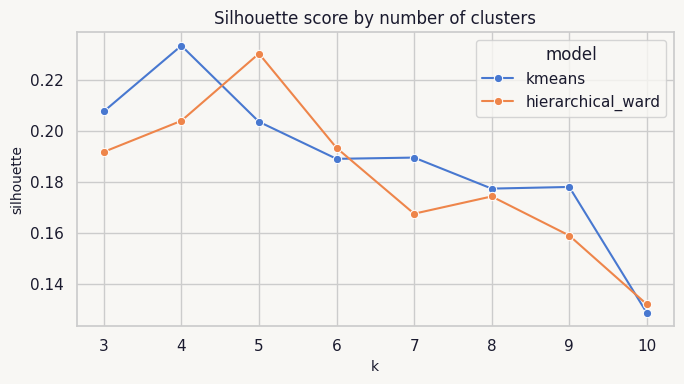

In [40]:
plot_metric_comparison(results_minmax)

### Visual Inspection

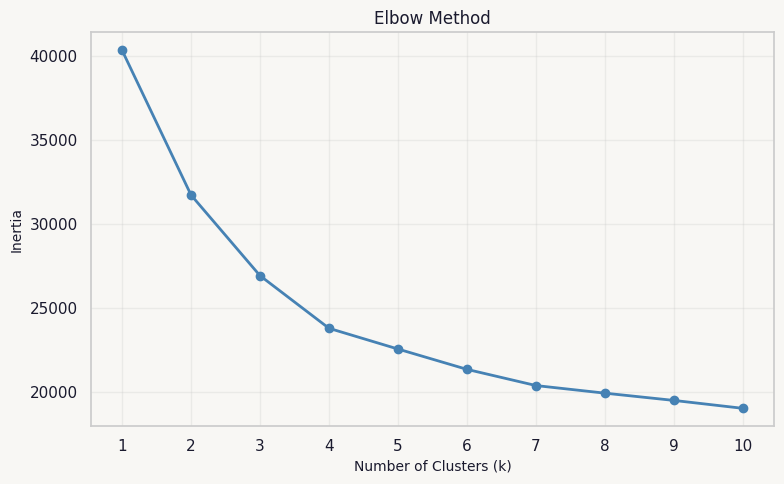

,k,inertia
0,1,40357.816602
1,2,31724.942675
2,3,26915.752022
3,4,23778.211285
4,5,22541.954859
5,6,21329.558147
6,7,20364.861272
7,8,19911.179753
8,9,19477.917433
9,10,19006.103365


In [42]:
compare_kmeans_inertia(clean_minmax, FEATURE_COLS)

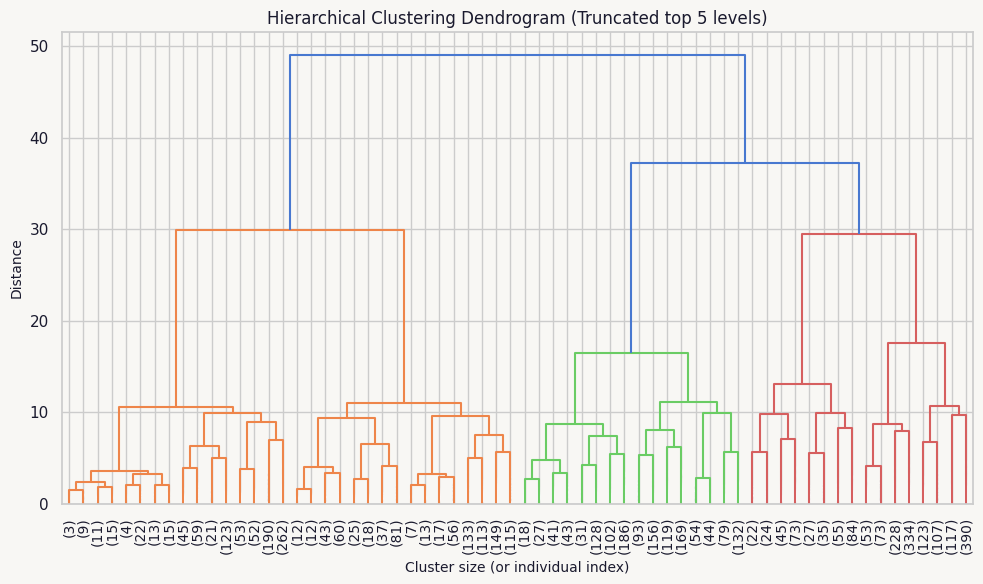

In [55]:
plot_dendrogram(clean_minmax, FEATURE_COLS)

### Cluster Analysis

In [ ]:
optimal_k_kmeans_minmax = 5
optimal_k_ward_minmax = 7

In [ ]:
kmeans_labels_minmax, kmeans_model_minmax = fit_final_hierarchical(clean_minmax, FEATURE_COLS, n_clusters=optimal_k_kmeans_minmax)
final_minmax_kmeans = add_clusters(clean_data, kmeans_labels_minmax, cluster_col='minmax_kmeans')

calculate_group_means(final_minmax_kmeans, cluster_col='minmax_kmeans')

In [ ]:
ward_labels_minmax, ward_model_minmax = fit_final_hierarchical(clean_minmax, FEATURE_COLS, n_clusters=optimal_k_ward_minmax)
final_minmax_ward = add_clusters(clean_data, ward_labels_minmax, cluster_col='minmax_ward')

calculate_group_means(final_minmax_ward, cluster_col='minmax_ward')